In [1]:
import qutip as qt
import qutip
import matplotlib
from qutip.piqs.piqs  import *
import numpy as np
import os
os.environ["MOSEKLM_LICENSE_FILE"] = "/Users/a46668993/Desktop/qer/mosek/mosek.lic"  # adjust path
from noisemodel import*
from codewords import*
from optimisation import*

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from optimisation import optimize

rho, l0, l1 = gross_13(phi=0.0)
gamma = np.logspace(-5, -2, 5)
dt = 0.1
infids = []
for g in gamma:
    kraus = noisemodel('local symmetric depolarizing', 13, g, dt)
    fid = optimize(l0, l1, kraus, solver='mosek')
    infid = abs(1.0 - float(fid))   # absolute value
    infids.append(infid)

infids = np.array(infids, dtype=float)
p_vals = gamma*dt

# avoid log(0) if any infidelity is numerically 0
mask = infids > 0

plt.figure(figsize=(6, 4))
plt.loglog(p_vals[mask], infids[mask], "o-", lw=1)
plt.xlabel("error probability p")
plt.ylabel("|1 - F|")
plt.title("local symmetric depolarizing noise on Gross 13-qubit code")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

Error: rescode.err_missing_license_file(1008): License cannot be located. The default search path is ':/Users/a46668993/mosek/mosek.lic:'.


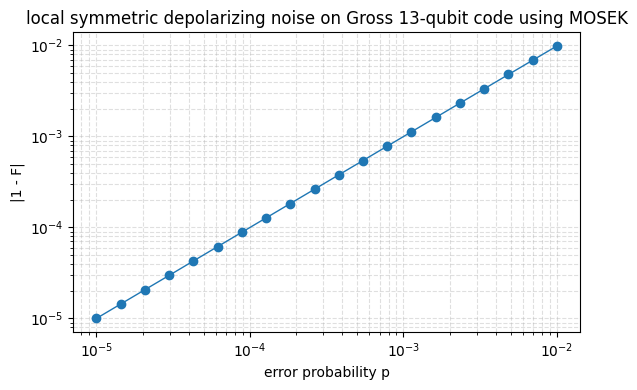

In [7]:
import numpy as np
import matplotlib.pyplot as plt

solver_name = "MOSEK"

p_vals = np.logspace(-5, -2, 20)

infids = []
for p in p_vals:
    fid, _ = optimize_recovery_fidelity(l0, l1, p=float(p))
    infid = abs(1.0 - float(fid))   # absolute value
    infids.append(infid)

infids = np.array(infids, dtype=float)

# avoid log(0) if any infidelity is numerically 0
mask = infids > 0

plt.figure(figsize=(6, 4))
plt.loglog(p_vals[mask], infids[mask], "o-", lw=1)
plt.xlabel("error probability p")
plt.ylabel("|1 - F|")
plt.title(f"local symmetric depolarizing noise on Gross 13-qubit code using {solver_name}")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [25]:
from qutip.piqs.piqs import Dicke

system = Dicke(13)
system


N = 13
Hilbert space dim = (56, 56)
Number of Dicke states = 56
Liouvillian space dim = (3136, 3136)

In [28]:
l0.shape[0]

56

In [22]:
L = system.liouvillian()
d = int(np.sqrt(L.shape[0]))
print(d)

6
